In [1]:
# from transformers import AutoTokenizer, AutoModelForCausalLM
from env_vars import CACHE_DIR
import ujson
import collections
import heapq
import copy
import matplotlib.pyplot as plt

In [4]:
# tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B", cache_dir=CACHE_DIR)

In [2]:
data = []
# with open('/cmlscratch/snawathe/cmsc828g-proj/results/inference_qwen3-4b_math500_G8_B16384_chunk0.jsonl', 'r') as f:
with open('/cmlscratch/snawathe/cmsc828g-proj/results/inference_qwen3-4b_math500_G4_B32768_chunk0.jsonl', 'r') as f:
	for line in f.readlines():
		data.append(ujson.loads(line))

In [14]:
len(data[0]['method_output']['outputs'][0]['token_ids'])

1483

In [3]:
sample_to_len_data = collections.defaultdict(list)
for sample in data:
	sample_to_len_data[sample['sample_idx']].extend(list(map(lambda x: len(x['token_ids']), sample['method_output']['outputs'])))

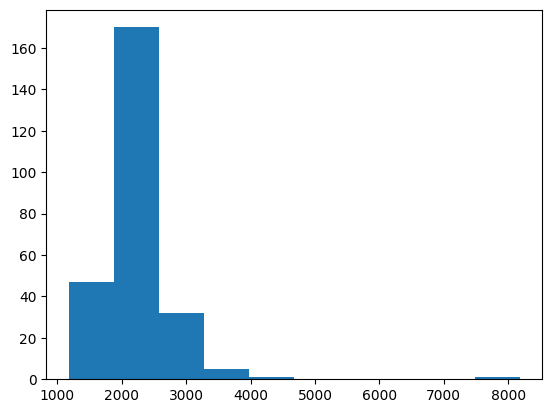

In [27]:
plt.hist(sample_to_len_data[5])
plt.show()

In [3]:
group_lens = []
for group_data in data:
	group_lens.append(list(map(lambda x: len(x['token_ids']), group_data['method_output']['outputs'])))

In [4]:
gmax = list(map(max, group_lens))
gsum = list(map(sum, group_lens))

In [5]:
gtimes = []
for group_data in data:
	gtimes.append(group_data['generation_time'])

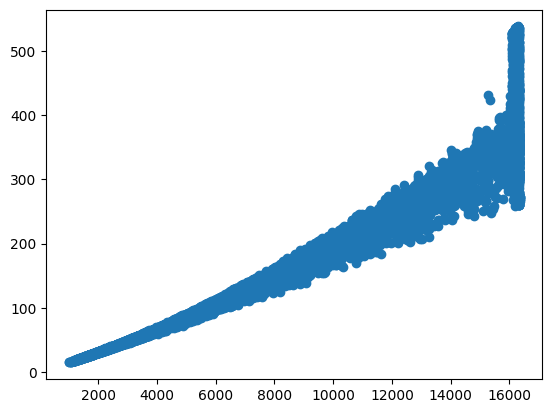

In [ ]:
plt.scatter(gmax, gtimes) # 16k
plt.show()

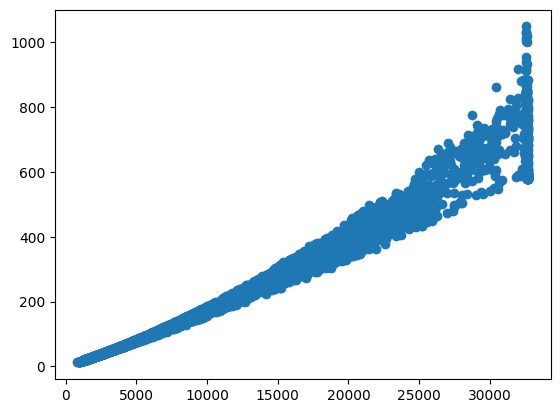

In [6]:
plt.scatter(gmax, gtimes) # 32k
plt.show()

In [ ]:
from scipy.stats import linregress # 16k

slope, intercept, r_value, p_value, std_err = linregress(gmax, gtimes)
print(f"Slope: {slope}")
print(f"R^2: {r_value**2}")

Slope: 0.024983639905050016
R^2: 0.9303682698406862


In [7]:
from scipy.stats import linregress # 32k

slope, intercept, r_value, p_value, std_err = linregress(gmax, gtimes)
print(f"Slope: {slope}")
print(f"R^2: {r_value**2}")

Slope: 0.021190698831949052
R^2: 0.974265506127685


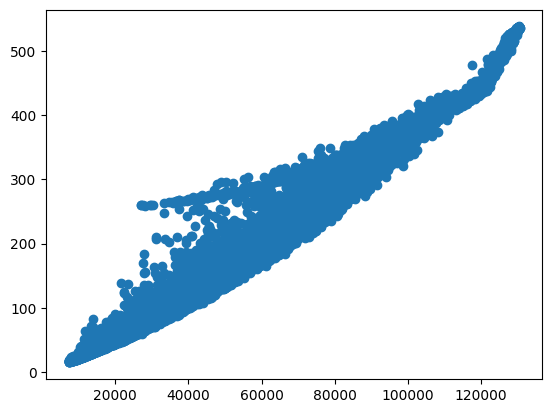

In [ ]:
plt.scatter(gsum, gtimes) # 16k
plt.show()

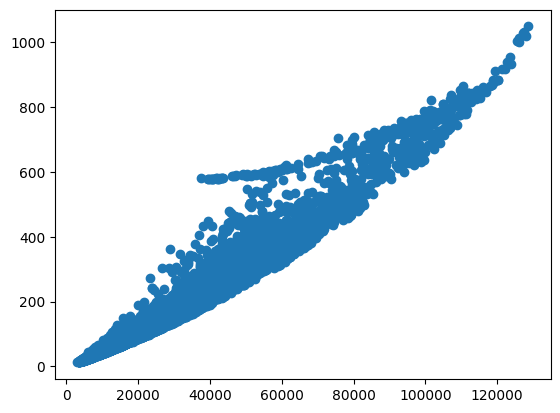

In [8]:
plt.scatter(gsum, gtimes) # 32k
plt.show()

In [ ]:
from scipy.stats import linregress # 16k

slope, intercept, r_value, p_value, std_err = linregress(gsum, gtimes)
print(f"Slope: {slope}")
print(f"R^2: {r_value**2}")

Slope: 0.0040366546104690084
R^2: 0.9684497638017225


In [9]:
from scipy.stats import linregress # 32k

slope, intercept, r_value, p_value, std_err = linregress(gsum, gtimes)
print(f"Slope: {slope}")
print(f"R^2: {r_value**2}")

Slope: 0.007159732455439228
R^2: 0.9479057989714981


In [4]:
def compute_epoch_time_for_ordering(order: list[int], epoch_data: dict[int, list[int]], num_nodes: int) -> int:
	assert set(order) == set(epoch_data.keys())
	times = [max(epoch_data[idx]) for idx in order]
	heap = []
	for _ in range(num_nodes):
		heapq.heappush(heap, times[0])
		times.pop(0)
	t = 0
	while heap:
		t = heapq.heappop(heap)
		if times:
			heapq.heappush(heap, t + times[0])
			times.pop(0)
	return t


def compute_time_for_ordering(order: list[int], sample_to_len_data: dict[int, list[int]], G: int, num_nodes: int) -> int:
	assert set(order) == set(sample_to_len_data.keys())
	sample_to_len_data = copy.deepcopy(sample_to_len_data)
	total_len = len(sample_to_len_data[0])
	tot_time = 0
	for _ in range(0, total_len, G):
		epoch_data = {}
		for k, v in sample_to_len_data.items():
			epoch_data[k] = v[:G]
			sample_to_len_data[k] = v[G:]
		tot_time += compute_epoch_time_for_ordering(order, epoch_data, num_nodes)
	return tot_time

In [5]:
sample_to_len_data_copy = copy.deepcopy(sample_to_len_data)
epoch_data = {}
for k, v in sample_to_len_data.items():
	epoch_data[k] = v[:8]
	sample_to_len_data[k] = v[8:]

In [6]:
compute_time_for_ordering(sorted(list(sample_to_len_data.keys())), sample_to_len_data, G=8, num_nodes=8)

6642919

In [7]:
idx_to_mean = {k: sum(v) / len(v) for k, v in sample_to_len_data.items()}
tups = [(mean, idx) for idx, mean in idx_to_mean.items()]
tups.sort()
asc_ordering = [idx for mean, idx in tups]
desc_ordering = asc_ordering[::-1]

In [8]:
compute_time_for_ordering(asc_ordering, sample_to_len_data, G=8, num_nodes=8)

6757778

In [9]:
6757778 / 6642919

1.0172904411449244

In [10]:
compute_time_for_ordering(desc_ordering, sample_to_len_data, G=8, num_nodes=8)

6520486

In [11]:
6520486 / 6642919

0.9815693974290519